# PnPMass with uncertainty quantification

Please check `README.md` before running this notebook.

PnPMass, noise-whitening data-fidelity, defined as
$$
f_\gamma(\kappa) = \frac12 \|\gamma - A\kappa\|_{\Sigma^{-1/2}}^2.
$$
Using DRUNet (noise-level-aware denoiser), forced mean centering, with DeepInverse PnP implementation.

- Comparison between denoisers trained with MSE vs MAE loss.
- Uncertainty quantification with moment networks and conformal prediction.
- Also include Wiener and MCALens, for comparison.

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import pickle
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch
import deepinv as dinv

from wlmmuq import CONFIG_DATA
import wlmmuq.utils as wlutils
import wlmmuq.data.torch as wlds
import wlmmuq.models.torch as wlnn
import wlmmuq.kappatng as wlktng
import wlmmuq.cosmos as wlcosmos
import wlmmuq.iterativemm.deepinverse as wlpnp
import wlmmuq.cqr as wlcqr

/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration file found in /home/leterme231/OneDrive/Documents/Code/weaklensing


2025-04-29 08:39:30.709281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 08:39:30.899764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745908770.979804   29813 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745908771.007835   29813 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-29 08:39:31.130583: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
path_to_test_set = "/path/to/test_set"
path_to_models = "/path/to/models"
pickle_dir = "/path/to/pickle/dir" # For saving reconstructions with Wiener and MCALens

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Load COSMOS galaxy shape catalog

In [6]:
imgsize = 304

In [7]:
cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
cat_cosmos_bright = wlktng.filter_by_redshifts(cat_cosmos_bright)
data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)
extent = data_dict["extent"]

In [8]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T

In [9]:
shapedisp = data_dict["shapedisp"]
ngal = data_dict["ngal"]
mask = data_dict["mask"]
std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0)
std_noise[~mask] = np.max(std_noise) # Set the noise standard deviation for masked data

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/utils.py:199: RuntimeWarning: divide by zero encountered in divide
  shapedisp / np.sqrt(ngal), posinf=std_noise_mask


## Estimate optimal step size

$\tau = 1 / \|B\|$, with $B = A^\ast \Sigma^{-1/2} A$.

In [10]:
nx, ny = std_noise.shape
def matvec(kappa_flattened):
    kappa = kappa_flattened.reshape(nx, ny)
    gamma = wlutils.get_shear_from_convergence(kappa, mask=mask, return_complex=True)
    gamma /= std_noise
    out = wlutils.get_convergence_from_shear(gamma, mask=mask, return_complex=True)
    return out.flatten()
rmatvec = matvec

In [11]:
linearop = sp.sparse.linalg.LinearOperator(shape=(nx*ny, nx*ny), matvec=matvec, rmatvec=rmatvec)
spectrnorm = sp.linalg.interpolative.estimate_spectral_norm(linearop, its=20)
optimal_step_size = 1 / spectrnorm

In [12]:
print(f"Optimal step size = {optimal_step_size:.1e}")

Optimal step size = 7.5e-02


In [13]:
std_noise = torch.tensor(std_noise, dtype=torch.float32).to(device)
mask = torch.tensor(mask, dtype=bool).to(device)

In [14]:
nimgs_test = 225
batch_size = 32
num_workers = 8
step_size = 1.4e-1

## Results training denoiser

- Size of the training set: 70560
- Batch size: 32
- Number of epochs: 20
- Learning rate: 1e-4, decreased by a factor of 10 every 5 epochs

### Training and validation loss

In [15]:
label_mse = 'Loss = MSE'
label_mae = 'Loss = MAE'

In [16]:
label_pe = 'Order-1 networks (mean estimates)'
label_uq = 'Order-2 networks (variance estimates)'

In [17]:
filename_denoiser_mse = (
    "denoiser_torch.DRUNet_small-model_scale_2.0e-1_scale-min_1.0e-1_"
    "meancentering_20250417_105424_pe_e20.pth.tar"
)
filename_denoiser_mae = (
    "denoiser_torch.DRUNet_small-model_scale_2.0e-1_scale-min_1.0e-1_"
    "meancentering_loss_mae_20250417_110413_pe_e20.pth.tar"
)

In [18]:
filename_denoiser_uq_mse = (
    "denoiser_torch.DRUNet_small-model_scale_2.0e-1_scale-min_1.0e-1_"
    "meancentering_20250417_105424_var_e20.pth.tar"
)
filename_denoiser_uq_mae = (
    "denoiser_torch.DRUNet_small-model_scale_2.0e-1_scale-min_1.0e-1_"
    "meancentering_loss_mae_20250417_110413_var_e20.pth.tar"
) # Order-2 network trained with MAE loss, not working well

In [19]:
colors = [d['color'] for d in plt.rcParams['axes.prop_cycle']]

In [20]:
linestyle_pe = '-'
linestyle_uq = '--'

color_mse = colors[0]
color_mae = colors[1]

In [21]:
checkpoint_mse = torch.load(
    os.path.join(path_to_models, filename_denoiser_mse)
)
checkpoint_mae = torch.load(
    os.path.join(path_to_models, filename_denoiser_mae)
)

In [22]:
checkpoint_uq_mse = torch.load(
    os.path.join(path_to_models, filename_denoiser_uq_mse)
)
checkpoint_uq_mae = torch.load(
    os.path.join(path_to_models, filename_denoiser_uq_mae)
)

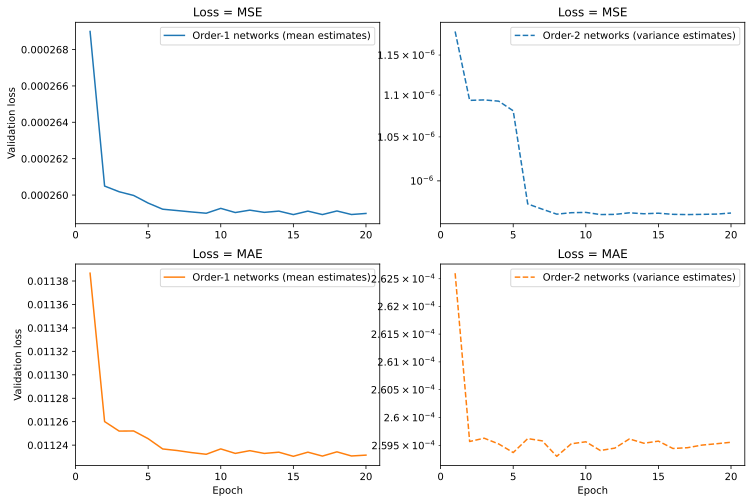

In [23]:
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.plot(
    np.arange(checkpoint_mse['epoch'] + 1) + 1, checkpoint_mse['loss'],
    label=label_pe, ls=linestyle_pe, c=color_mse
)
plt.ylabel('Validation loss')
plt.xticks(np.arange(21, step=5))
plt.title(label_mse)
plt.legend()

plt.subplot(222)
plt.plot(
    np.arange(checkpoint_uq_mse['epoch'] + 1) + 1, checkpoint_uq_mse['loss'],
    label=label_uq, ls=linestyle_uq, c=color_mse
)
plt.xticks(np.arange(21, step=5))
plt.title(label_mse)
plt.legend()
plt.yscale('log')

plt.subplot(223)
plt.plot(
    np.arange(checkpoint_mae['epoch'] + 1) + 1, checkpoint_mae['loss'],
    label=label_pe, ls=linestyle_pe, c=color_mae
)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.xticks(np.arange(21, step=5))
plt.title(label_mae)
plt.legend()

plt.subplot(224)
plt.plot(
    np.arange(checkpoint_uq_mae['epoch'] + 1) + 1, checkpoint_uq_mae['loss'],
    label=label_uq, ls=linestyle_uq, c=color_mae
)
plt.xlabel('Epoch')
plt.xticks(np.arange(21, step=5))
plt.title(label_mae)
plt.legend()
plt.yscale('log')

plt.show()

### Load trained models

In [24]:
model_mse = wlnn.DRUNet(
    map_size=imgsize, meancentering=True, small_model=True, pretrained=None
)
model_mae = wlnn.DRUNet(
    map_size=imgsize, meancentering=True, small_model=True, pretrained=None
)

model_mse.load_state_dict(checkpoint_mse['state_dict'])
model_mae.load_state_dict(checkpoint_mae['state_dict'])

model_mse.to(device).eval()
model_mae.to(device).eval()

DRUNet(
  (m_head): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (m_down1): Sequential(
    (0): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.0001, momentum=0.9, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (1): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.0001, momentum=0.9, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (2): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1)

In [25]:
model_uq_mse = wlnn.DRUNet(
    map_size=imgsize, onlypositive=True, small_model=True, pretrained=None
)
model_uq_mae = wlnn.DRUNet(
    map_size=imgsize, onlypositive=True, small_model=True, pretrained=None
)

model_uq_mse.load_state_dict(checkpoint_uq_mse['state_dict'])
model_uq_mae.load_state_dict(checkpoint_uq_mae['state_dict'])

model_uq_mse.to(device).eval()
model_uq_mae.to(device).eval()

DRUNet(
  (m_head): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (m_down1): Sequential(
    (0): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.0001, momentum=0.9, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (1): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.0001, momentum=0.9, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (2): ResBlock(
      (res): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1)

## PnPMass

In [26]:
niter = 3

### Load test set, physics, data fidelity and priors

For the data fidelity, we use the square root of the noise level (non-Bayesian data fidelity):
$$
f_\gamma(\kappa) = \frac12 \|\gamma - A\kappa\|_{\Sigma^{-1/2}}^2.
$$

In [27]:
test_dataset = wlds.HDF5DatasetMassMapping(
    hdf5_filepath=path_to_test_set, nimgs=nimgs_test, batch_size=batch_size,
    std_noise=std_noise.cpu(), mask=mask.cpu(), inpainting=True, shuffle=False,
    output_shape=imgsize, newaxis=True, num_workers=num_workers
)
test_dataloader = test_dataset.to_dataloader()

/home/leterme231/OneDrive/Documents/Code/weaklensing/wlmmuq/data/base_dataset.py:315: UserWarning: The 'filename_ori' dataset is missing; input images will not be sorted.
  warnings.warn(


In [28]:
physics = wlpnp.MassMapping(sigma=std_noise, mask=mask).to(device)
data_fidelity = wlpnp.Mahalanobis(sigma=torch.sqrt(std_noise)).to(device) # torch.sqrt is on purpose

In [29]:
def zero_init(y: torch.Tensor, _unused_physics):
    """The optimization algorithm is initialized with zero-valued tensors"""
    x_init = torch.zeros_like(y, dtype=torch.float32, device=y.device)
    z_init = torch.zeros_like(y, dtype=torch.float32, device=y.device)
    return {"est": (x_init, z_init)}

In [30]:
prior_mse = wlpnp.PnP(model_mse).to(device)
prior_uq_mse = wlpnp.PnP(model_uq_mse).to(device)
pnp_mse = wlpnp.optim_builder(
    iteration="PGD", prior=prior_mse, prior_uq=prior_uq_mse,
    data_fidelity=data_fidelity,
    early_stop=False, max_iter=niter, custom_init=zero_init,
    verbose=True, params_algo={"stepsize": step_size, "g_param": step_size},
) # The step size is equal to the noise level in the denoiser

In [31]:
prior_mae = wlpnp.PnP(model_mae)
prior_uq_mae = wlpnp.PnP(model_uq_mae)
pnp_mae = wlpnp.optim_builder(
    iteration="PGD", prior=prior_mae, prior_uq=prior_uq_mae,
    data_fidelity=data_fidelity,
    early_stop=False, max_iter=niter, custom_init=zero_init,
    verbose=True, params_algo={"stepsize": step_size, "g_param": step_size},
) # The step size is equal to the noise level in the denoiser

### Run PnPMass

In [32]:
listof_kappa_pnp_mse_test = []
listof_kappa_pnp_mae_test = []
listof_var_pnp_mse_test = []
listof_var_pnp_mae_test = []

In [33]:
test_dataloader_iter = iter(test_dataloader)
while True:
    try:
        _, gamma_noisy_test = next(test_dataloader_iter)
    except StopIteration:
        break
    gamma_noisy_test = gamma_noisy_test.to(device)
    with torch.no_grad():
        kappa_pnp_mse_test, var_pnp_mse_test = pnp_mse(gamma_noisy_test, physics)
        kappa_pnp_mae_test, var_pnp_mae_test = pnp_mae(gamma_noisy_test, physics)

    listof_kappa_pnp_mse_test.append(kappa_pnp_mse_test)
    listof_kappa_pnp_mae_test.append(kappa_pnp_mae_test)
    listof_var_pnp_mse_test.append(var_pnp_mse_test)
    listof_var_pnp_mae_test.append(var_pnp_mae_test)

/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/leterme231/miniconda3/envs/wl-pycs/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tenso

In [34]:
kappa_pnp_mse_test = torch.cat(listof_kappa_pnp_mse_test, dim=0)
del listof_kappa_pnp_mse_test
kappa_pnp_mae_test = torch.cat(listof_kappa_pnp_mae_test, dim=0)
del listof_kappa_pnp_mae_test
var_pnp_mse_test = torch.cat(listof_var_pnp_mse_test, dim=0)
del listof_var_pnp_mse_test
var_pnp_mae_test = torch.cat(listof_var_pnp_mae_test, dim=0)
del listof_var_pnp_mae_test

### Visualize input, target and prediction

In [35]:
kappa_test, gamma_noisy_test = test_dataset.load_batch(get_all_images=True)
kappa_test = kappa_test.to(device)
gamma_noisy_test = gamma_noisy_test.to(device)

In [36]:
vmin = torch.min(kappa_test).item()
vmax = torch.max(kappa_test).item()
saturation = 0.4
vmax_gamma = 0.14
vmax_sqdiff = 4e-3

In [37]:
idx = 0

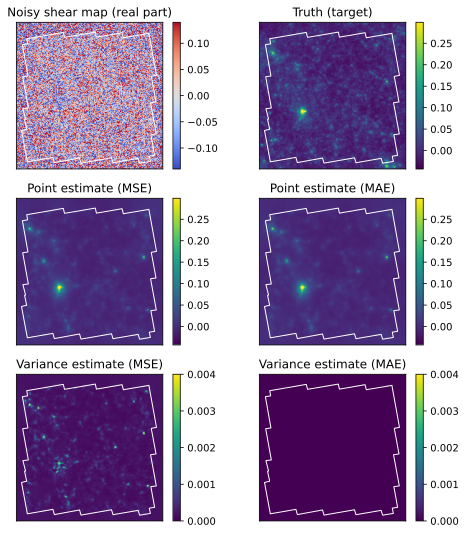

In [38]:
plt.figure(figsize=(8, 9))
plt.subplot(321)
wlutils.skyshow(
    gamma_noisy_test.real.cpu()[idx, 0], title=f"Noisy shear map (real part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(322)
wlutils.skyshow(
    kappa_test.cpu()[idx, 0], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(323)
wlutils.skyshow(
    kappa_pnp_mse_test.cpu()[idx, 0], title="Point estimate (MSE)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(324)
wlutils.skyshow(
    kappa_pnp_mae_test.cpu()[idx, 0], title="Point estimate (MAE)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(325)
wlutils.skyshow(
    var_pnp_mse_test.cpu()[idx, 0], title="Variance estimate (MSE)",
    vmin=0., vmax=vmax_sqdiff, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(326)
wlutils.skyshow(
    var_pnp_mae_test.cpu()[idx, 0], title="Variance estimate (MAE)",
    vmin=0., vmax=vmax_sqdiff, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.show()

## Wiener and MCALens

Convergence maps reconstructed with the following scripts (commit nb `dde28a1cddfa0aa84037a1690d13e9d23b8d9603`):
```bash
python scripts/massmapping.py wiener wiener_niter_12_nimgs_225_${datetime} /home/leterme231/Documents/Data/kappaTNG_cropped/LP001_cropped.hdf5 --niter 12 --nimgs 225 -b 45 --seed 42 -v
```
```bash
python scripts/massmapping.py mcalens mcalens_niter_${niter_mcalens}_Nsigma_5_nimgs_225_${datetime} /home/leterme231/Documents/Data/kappaTNG_cropped/LP001_cropped.hdf5 --niter $niter_mcalens --Nsigma 5 --nimgs 225 -b 45 --seed 42 -v
```

In [39]:
label_pnp_mse = "PnPMass (MSE)"
label_pnp_mae = "PnPMass (MAE)"
label_wiener = "Wiener"
label_mcalens_niter_12 = "MCALens (12 iterations)"
label_mcalens_niter_100 = "MCALens (100 iterations)"

In [40]:
filename_wiener_test = 'wiener_niter_12_nimgs_225_20250425_161425.npy'
filename_mcalens_niter_12_test = 'mcalens_niter_12_Nsigma_5_nimgs_225_20250425_161238.npy'
filename_mcalens_niter_100_test = 'mcalens_niter_100_Nsigma_5_nimgs_225_20250425_161218.npy'

In [41]:
kappa_wiener_test = np.load(os.path.join(pickle_dir, filename_wiener_test))
kappa_mcalens_niter_12_test = np.load(os.path.join(pickle_dir, filename_mcalens_niter_12_test))
kappa_mcalens_niter_100_test = np.load(os.path.join(pickle_dir, filename_mcalens_niter_100_test))

In [42]:
kappa_wiener_test = torch.tensor(kappa_wiener_test, dtype=torch.float32).to(device)
kappa_mcalens_niter_12_test = torch.tensor(kappa_mcalens_niter_12_test, dtype=torch.float32).to(device)
kappa_mcalens_niter_100_test = torch.tensor(kappa_mcalens_niter_100_test, dtype=torch.float32).to(device)

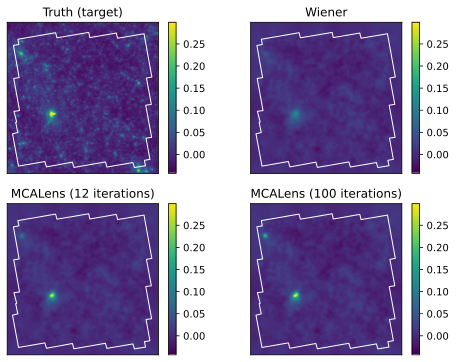

In [43]:
plt.figure(figsize=(8, 6))
plt.subplot(221)
wlutils.skyshow(
    kappa_test.cpu()[idx, 0], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(222)
wlutils.skyshow(
    kappa_wiener_test.cpu()[idx], title=label_wiener,
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(223)
wlutils.skyshow(
    kappa_mcalens_niter_12_test.cpu()[idx], title=label_mcalens_niter_12,
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(224)
wlutils.skyshow(
    kappa_mcalens_niter_100_test.cpu()[idx], title=label_mcalens_niter_100,
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.show()

## Uncertainty quantification

### UQ parameters

In [44]:
confidence = 2. # Level of confidence (n-sigma)
alpha = wlutils.get_alpha_from_confidence(confidence)

min_nimgs_calib = wlutils.get_min_nimgs_calib(alpha)
print(f"Confidence level of {confidence}-sigma --> alpha = {alpha:.1%}")
print(f"Smallest possible size for the calibration set = {min_nimgs_calib}")

Confidence level of 2.0-sigma --> alpha = 4.6%
Smallest possible size for the calibration set = 21


In [45]:
nimgs_calib = 100
nimgs_test -= nimgs_calib

### Remove channel dimension from tensors

In [46]:
kappa_test = kappa_test.squeeze(-3)
kappa_pnp_mse_test = kappa_pnp_mse_test.squeeze(-3)
kappa_pnp_mae_test = kappa_pnp_mae_test.squeeze(-3)
var_pnp_mse_test = var_pnp_mse_test.squeeze(-3)
var_pnp_mae_test = var_pnp_mae_test.squeeze(-3)

### Get residuals

In [47]:
# TODO: remove this after bugfix
var_pnp_mse_test = wlutils.maximum(var_pnp_mse_test, 0.)
var_pnp_mae_test = wlutils.maximum(var_pnp_mae_test, 0.)

In [48]:
std_pnp_mse_test = torch.sqrt(var_pnp_mse_test)
res_pnp_mse_test = confidence * std_pnp_mse_test

In [49]:
std_pnp_mae_test = torch.sqrt(var_pnp_mae_test)
res_pnp_mae_test = confidence * std_pnp_mae_test

Wiener and MCALens: no initial UQ

In [50]:
res_wiener_test = 0.
res_mcalens_niter_12_test = 0.
res_mcalens_niter_100_test = 0.

### Split test and calibration sets

In [51]:
[
    kappa_calib,
    kappa_pnp_mse_calib, kappa_pnp_mae_calib,
    kappa_wiener_calib, kappa_mcalens_niter_12_calib, kappa_mcalens_niter_100_calib,
    res_pnp_mse_calib, res_pnp_mae_calib,
    res_wiener_calib, res_mcalens_niter_12_calib, res_mcalens_niter_100_calib
], [
    kappa_test,
    kappa_pnp_mse_test, kappa_pnp_mae_test,
    kappa_wiener_test, kappa_mcalens_niter_12_test, kappa_mcalens_niter_100_test,
    res_pnp_mse_test, res_pnp_mae_test,
    res_wiener_test, res_mcalens_niter_12_test, res_mcalens_niter_100_test
] = wlutils.split_test_calib(
    [
        kappa_test,
        kappa_pnp_mse_test, kappa_pnp_mae_test,
        kappa_wiener_test, kappa_mcalens_niter_12_test, kappa_mcalens_niter_100_test,
        res_pnp_mse_test, res_pnp_mae_test,
        res_wiener_test, res_mcalens_niter_12_test, res_mcalens_niter_100_test
    ],
    nimgs_calib, calib_first=False
) # First the test set; then the calibration set

print(f"Size of the calibration set = {kappa_calib.shape[0]}")
print(f"Size of the test set = {kappa_test.shape[0]}")

Size of the calibration set = 100
Size of the test set = 125


### Compute reconstruction accuracy

In [52]:
rmse_pnp_mse_test = wlutils.rmse(
    kappa_pnp_mse_test, kappa_test, mask=mask, meancentering=True
)
rmse_pnp_mae_test = wlutils.rmse(
    kappa_pnp_mae_test, kappa_test, mask=mask, meancentering=True
)
rmse_wiener_test = wlutils.rmse(
    kappa_wiener_test, kappa_test, mask=mask, meancentering=True
)
rmse_mcalens_niter_12_test = wlutils.rmse(
    kappa_mcalens_niter_12_test, kappa_test, mask=mask, meancentering=True
)
rmse_mcalens_niter_100_test = wlutils.rmse(
    kappa_mcalens_niter_100_test, kappa_test, mask=mask, meancentering=True
)

In [53]:
om = 3
print(
    f"{label_pnp_mse} --> RMSE = {10**om * torch.mean(rmse_pnp_mse_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_pnp_mse_test):.2f}e-{om}"
)
print(
    f"{label_pnp_mae} --> RMSE = {10**om * torch.mean(rmse_pnp_mae_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_pnp_mae_test):.2f}e-{om}"
)
print(
    f"{label_wiener} --> RMSE = {10**om * torch.mean(rmse_wiener_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_wiener_test):.2f}e-{om}"
)
print(
    f"{label_mcalens_niter_12} --> RMSE = {10**om * torch.mean(rmse_mcalens_niter_12_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_mcalens_niter_12_test):.2f}e-{om}"
)
print(
    f"{label_mcalens_niter_100} --> RMSE = {10**om * torch.mean(rmse_mcalens_niter_100_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(rmse_mcalens_niter_100_test):.2f}e-{om}"
)

PnPMass (MSE) --> RMSE = 17.54e-3 +/- 0.90e-3
PnPMass (MAE) --> RMSE = 17.55e-3 +/- 0.92e-3
Wiener --> RMSE = 18.27e-3 +/- 1.20e-3
MCALens (12 iterations) --> RMSE = 17.98e-3 +/- 0.96e-3
MCALens (100 iterations) --> RMSE = 18.04e-3 +/- 0.96e-3


### CQR

In [54]:
addcqr = wlcqr.AddCQR(alpha)

In [55]:
res_pnp_mse_addcqr_test, _, _ = addcqr.conformalize(
    res_pnp_mse_test, kappa_pnp_mse_calib, res_pnp_mse_calib, kappa_calib
)
res_pnp_mae_addcqr_test, _, _ = addcqr.conformalize(
    res_pnp_mae_test, kappa_pnp_mae_calib, res_pnp_mae_calib, kappa_calib
)
res_wiener_addcqr_test, _, _ = addcqr.conformalize(
    res_wiener_test, kappa_wiener_calib, res_wiener_calib, kappa_calib
)
res_mcalens_niter_12_addcqr_test, _, _ = addcqr.conformalize(
    res_mcalens_niter_12_test, kappa_mcalens_niter_12_calib,
    res_mcalens_niter_12_calib, kappa_calib
)
res_mcalens_niter_100_addcqr_test, _, _ = addcqr.conformalize(
    res_mcalens_niter_100_test, kappa_mcalens_niter_100_calib,
    res_mcalens_niter_100_calib, kappa_calib
)

### Visualize bounds

In [56]:
skyshow_pred_bounds = wlutils.KappamapVisualizer(
    extent=extent, boundaries=(ra, dec), vmin=saturation*vmin, vmax=saturation*vmax,
    vmax_bounds=0.23, plot_colorbar=True
)

lowerbound_mse, upperbound_mse = skyshow_pred_bounds(
    kappa_pnp_mse_test[idx], res_pnp_mse_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
lowerbound_mae, upperbound_mae = skyshow_pred_bounds(
    kappa_pnp_mae_test[idx], res_pnp_mae_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
lowerbound_wiener, upperbound_wiener = skyshow_pred_bounds(
    kappa_wiener_test[idx], res_wiener_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
lowerbound_mcalens_niter_12, upperbound_mcalens_niter_12 = skyshow_pred_bounds(
    kappa_mcalens_niter_12_test[idx], res_mcalens_niter_12_addcqr_test[idx],
    kappa_test[idx], mask=mask
)
lowerbound_mcalens_niter_100, upperbound_mcalens_niter_100 = skyshow_pred_bounds(
    kappa_mcalens_niter_100_test[idx], res_mcalens_niter_100_addcqr_test[idx],
    kappa_test[idx], mask=mask
)

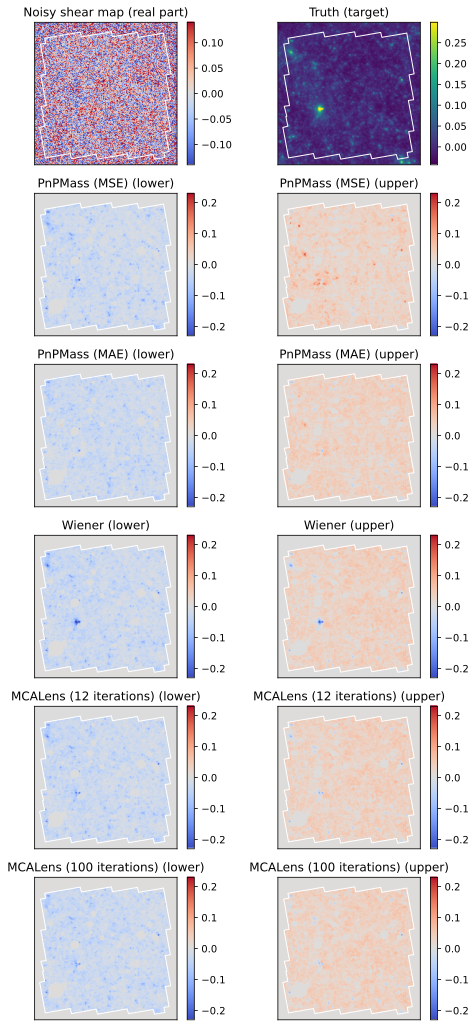

In [57]:
plt.figure(figsize=(8, 18))
plt.subplot(6, 2, 1)
wlutils.skyshow(
    gamma_noisy_test.real.cpu()[idx, 0], title=f"Noisy shear map (real part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(6, 2, 2)
wlutils.skyshow(
    kappa_test.cpu()[idx], title="Truth (target)",
    vmin=vmin, vmax=saturation*vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True
)
plt.subplot(6, 2, 3)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_mse, title=f"{label_pnp_mse} (lower)"
)
plt.subplot(6, 2, 4)
skyshow_pred_bounds.skyshow_bound(
    upperbound_mse, title=f"{label_pnp_mse} (upper)"
)
plt.subplot(6, 2, 5)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_mae, title=f"{label_pnp_mae} (lower)"
)
plt.subplot(6, 2, 6)
skyshow_pred_bounds.skyshow_bound(
    upperbound_mae, title=f"{label_pnp_mae} (upper)"
)
plt.subplot(6, 2, 7)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_wiener, title=f"{label_wiener} (lower)"
)
plt.subplot(6, 2, 8)
skyshow_pred_bounds.skyshow_bound(
    upperbound_wiener, title=f"{label_wiener} (upper)"
)
plt.subplot(6, 2, 9)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_mcalens_niter_12, title=f"{label_mcalens_niter_12} (lower)"
)
plt.subplot(6, 2, 10)
skyshow_pred_bounds.skyshow_bound(
    upperbound_mcalens_niter_12, title=f"{label_mcalens_niter_12} (upper)"
)
plt.subplot(6, 2, 11)
skyshow_pred_bounds.skyshow_bound(
    lowerbound_mcalens_niter_100, title=f"{label_mcalens_niter_100} (lower)"
)
plt.subplot(6, 2, 12)
skyshow_pred_bounds.skyshow_bound(
    upperbound_mcalens_niter_100, title=f"{label_mcalens_niter_100} (upper)"
)
plt.show()

### Miscoverage rate (all pixels)

In [58]:
ylabel_err = \
    r"$L\left(\boldsymbol{\kappa}_i,\, \hat{\boldsymbol{\kappa}}_i^-,\, \hat{\boldsymbol{\kappa}}_i^+\right)$"
xticklabels = ['Uncalibrated', 'Additive CQR']

In [59]:
lower_bound_proba, upper_bound_proba = addcqr.get_bounds_proba(nimgs_calib)

In [60]:
err_pnp_mse_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_mse_test, res_pnp_mse_test, kappa_test, mask=mask
)
err_pnp_mse_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_mse_test, res_pnp_mse_addcqr_test, kappa_test, mask=mask
)

In [61]:
err_pnp_mae_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_mae_test, res_pnp_mae_test, kappa_test, mask=mask
)
err_pnp_mae_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_pnp_mae_test, res_pnp_mae_addcqr_test, kappa_test, mask=mask
)

We do not compute the error rate before calibration for Wiener and MCALens (it would be 100%).

In [62]:
err_wiener_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_wiener_test, res_wiener_addcqr_test, kappa_test, mask=mask
)
err_mcalens_niter_12_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_mcalens_niter_12_test, res_mcalens_niter_12_addcqr_test, kappa_test, mask=mask
)
err_mcalens_niter_100_addcqr_test, _, _, _ = wlutils.get_metrics(
    kappa_mcalens_niter_100_test, res_mcalens_niter_100_addcqr_test, kappa_test, mask=mask
)

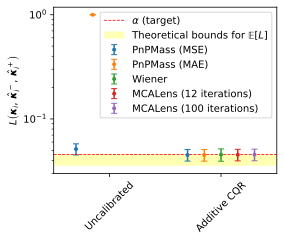

In [63]:
wlutils.plot_means_errs(
    [
        [err_pnp_mse_test.mean().cpu(), err_pnp_mse_addcqr_test.mean().cpu()],
        [err_pnp_mae_test.mean().cpu(), err_pnp_mae_addcqr_test.mean().cpu()],
        [None, err_wiener_addcqr_test.mean().cpu()],
        [None, err_mcalens_niter_12_addcqr_test.mean().cpu()],
        [None, err_mcalens_niter_100_addcqr_test.mean().cpu()]
    ],
    [
        [err_pnp_mse_test.std().cpu(), err_pnp_mse_addcqr_test.std().cpu()],
        [err_pnp_mae_test.std().cpu(), err_pnp_mae_addcqr_test.std().cpu()],
        [None, err_wiener_addcqr_test.std().cpu()],
        [None, err_mcalens_niter_12_addcqr_test.std().cpu()],
        [None, err_mcalens_niter_100_addcqr_test.std().cpu()]
    ],
    [
        label_pnp_mse, label_pnp_mae, label_wiener, label_mcalens_niter_12, label_mcalens_niter_100
    ], xticklabels=xticklabels, alpha=alpha,
    ylabel=ylabel_err, drawbounds=True, y_lower=lower_bound_proba, y_upper=upper_bound_proba,
    ymin=0.03, figsize=(4, 3), logscale=True, savefig=False
)

### Mean length of prediction intervals

In [64]:
predinterv_pnp_mse_test = wlutils.mean_predinterv(
    kappa_pnp_mse_test - res_pnp_mse_test,
    kappa_pnp_mse_test + res_pnp_mse_test,
    mask=mask
)
predinterv_pnp_mse_addcqr_test = wlutils.mean_predinterv(
    kappa_pnp_mse_test - res_pnp_mse_addcqr_test,
    kappa_pnp_mse_test + res_pnp_mse_addcqr_test,
    mask=mask
)

In [65]:
predinterv_pnp_mae_test = wlutils.mean_predinterv(
    kappa_pnp_mae_test - res_pnp_mae_test,
    kappa_pnp_mae_test + res_pnp_mae_test,
    mask=mask
)
predinterv_pnp_mae_addcqr_test = wlutils.mean_predinterv(
    kappa_pnp_mae_test - res_pnp_mae_addcqr_test,
    kappa_pnp_mae_test + res_pnp_mae_addcqr_test,
    mask=mask
)

We do not compute the error bar sizes before calibration for Wiener and MCALens (it would be 0).

In [66]:
predinterv_wiener_addcqr_test = wlutils.mean_predinterv(
    kappa_wiener_test - res_wiener_addcqr_test,
    kappa_wiener_test + res_wiener_addcqr_test,
    mask=mask
)
predinterv_mcalens_niter_12_addcqr_test = wlutils.mean_predinterv(
    kappa_mcalens_niter_12_test - res_mcalens_niter_12_addcqr_test,
    kappa_mcalens_niter_12_test + res_mcalens_niter_12_addcqr_test,
    mask=mask
)
predinterv_mcalens_niter_100_addcqr_test = wlutils.mean_predinterv(
    kappa_mcalens_niter_100_test - res_mcalens_niter_100_addcqr_test,
    kappa_mcalens_niter_100_test + res_mcalens_niter_100_addcqr_test,
    mask=mask
)

In [67]:
om = 3
print(f"{label_pnp_mse}:")
print(
    f"    mean length before calibration = {10**om * torch.mean(predinterv_pnp_mse_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_mse_test):.2f}e-{om}"
)
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_pnp_mse_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_mse_addcqr_test):.2f}e-{om}"
)
print(f"{label_pnp_mae}:")
print(
    f"    mean length before calibration = {10**om * torch.mean(predinterv_pnp_mae_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_mae_test):.2f}e-{om}"
)
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_pnp_mae_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_pnp_mae_addcqr_test):.2f}e-{om}"
)
print(f"{label_wiener}:")
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_wiener_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_wiener_addcqr_test):.2f}e-{om}"
)
print(f"{label_mcalens_niter_12}:")
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_mcalens_niter_12_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_mcalens_niter_12_addcqr_test):.2f}e-{om}"
)
print(f"{label_mcalens_niter_100}:")
print(
    f"    mean length after calibration = {10**om * torch.mean(predinterv_mcalens_niter_100_addcqr_test):.2f}e-{om} "
    f"+/- {1e3*torch.std(predinterv_mcalens_niter_100_addcqr_test):.2f}e-{om}"
)

PnPMass (MSE):
    mean length before calibration = 60.05e-3 +/- 0.34e-3
    mean length after calibration = 67.71e-3 +/- 0.34e-3
PnPMass (MAE):
    mean length before calibration = 0.00e-3 +/- 0.00e-3
    mean length after calibration = 70.34e-3 +/- 0.00e-3
Wiener:
    mean length after calibration = 70.94e-3 +/- 0.00e-3
MCALens (12 iterations):
    mean length after calibration = 70.30e-3 +/- 0.00e-3
MCALens (100 iterations):
    mean length after calibration = 70.80e-3 +/- 0.00e-3


## Summary plot

### Retrieve DeepMass statistics

In [68]:
rmse_deepmass_test = np.load(
    os.path.join(pickle_dir, 'rmse_deepmass_20241023.npy'), allow_pickle=True
)

In [69]:
def get_mean_err_predinterv(filename):

    fn = os.path.join(pickle_dir, f'{filename}.cqr')
    with open(fn, 'rb') as f:
        _, list_of_err, list_of_predinterv, _, _ = pickle.load(f)

    # Keep uncalibrated and additive CQR, respectively
    list_of_err = list_of_err[:2]
    list_of_predinterv = list_of_predinterv[:2]

    out = (
        tuple([
            np.mean(err) for err in list_of_err
        ]),
        tuple([
            np.mean(predinterv) for predinterv in list_of_predinterv
        ])
    )

    return out

In [70]:
(
    err_deepmass_test, err_deepmass_addcqr_test
), (
    predinterv_deepmass_test, predinterv_deepmass_addcqr_test
) = get_mean_err_predinterv('deepmass_20241023')

err_deepmass_test = torch.tensor(err_deepmass_test, dtype=torch.float32).to(device)
err_deepmass_addcqr_test = torch.tensor(err_deepmass_addcqr_test, dtype=torch.float32).to(device)
predinterv_deepmass_test = torch.tensor(predinterv_deepmass_test, dtype=torch.float32).to(device)
predinterv_deepmass_addcqr_test = torch.tensor(predinterv_deepmass_addcqr_test, dtype=torch.float32).to(device)

In [71]:
label_deepmass = "DeepMass"

### Plot statistics

In [72]:
rmse = [
    rmse_wiener_test.mean().item(),
    rmse_mcalens_niter_12_test.mean().item(),
    rmse_mcalens_niter_100_test.mean().item(),
    rmse_deepmass_test.mean().item(),
    rmse_pnp_mse_test.mean().item(),
    rmse_pnp_mae_test.mean().item()
]
rmse = np.array(rmse)

In [73]:
predinterv = [
    None,
    None,
    None,
    predinterv_deepmass_test.mean().item(),
    predinterv_pnp_mse_test.mean().item(),
    predinterv_pnp_mae_test.mean().item()
]
predinterv_addcqr = [
    predinterv_wiener_addcqr_test.mean().item(),
    predinterv_mcalens_niter_12_addcqr_test.mean().item(),
    predinterv_mcalens_niter_100_addcqr_test.mean().item(),
    predinterv_deepmass_addcqr_test.mean().item(),
    predinterv_pnp_mse_addcqr_test.mean().item(),
    predinterv_pnp_mae_addcqr_test.mean().item()
]
predinterv = np.array(predinterv)
predinterv_addcqr = np.array(predinterv_addcqr)

In [74]:
err = [
    None,
    None,
    None,
    err_deepmass_test.mean().item(),
    err_pnp_mse_test.mean().item(),
    err_pnp_mae_test.mean().item()
]
err_addcqr = [
    err_wiener_addcqr_test.mean().item(),
    err_mcalens_niter_12_addcqr_test.mean().item(),
    err_mcalens_niter_100_addcqr_test.mean().item(),
    err_deepmass_addcqr_test.mean().item(),
    err_pnp_mse_addcqr_test.mean().item(),
    err_pnp_mae_addcqr_test.mean().item()
]
err = np.array(err)
err_addcqr = np.array(err_addcqr)

In [75]:
methods = [
    label_wiener, label_mcalens_niter_12, label_mcalens_niter_100,
    label_deepmass, label_pnp_mse, label_pnp_mae
]

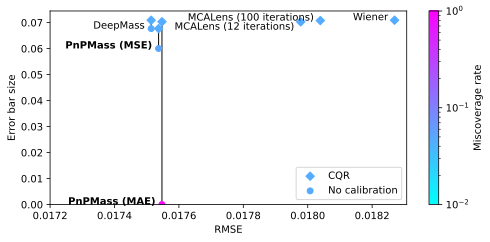

In [81]:
colormap = cm.cool
norm = mcolors.LogNorm(vmin=0.01, vmax=1.)

plt.figure(figsize=(8, 3.5))

plt.scatter(
    rmse, predinterv_addcqr,
    marker="D", c=err_addcqr,
    cmap=colormap, norm=norm, label="CQR", zorder=2
)
mask = predinterv != None # Array of booleans. Do not use `predinterv is not None` as it returns False
sc = plt.scatter(
    rmse[mask], predinterv[mask],
    marker="o", c=err[mask],
    cmap=colormap, norm=norm, label="No calibration", zorder=2
)

plt.vlines(
    rmse[mask], ymin=predinterv[mask],
    ymax=predinterv_addcqr[mask], colors='k', linewidth=1., zorder=1
)

x_offsets = [-2e-5, -2e-5, -2e-5, -2e-5, -2e-5, -2e-5]
y_offsets = [0., -0.003, 0., 0., 0., 0., 0.]
positions = ["right", "right", "right", "right", "right", "right"]
weights = 4 * ['normal'] + 2 * ['bold']
altitudes = []
for y, z in zip(predinterv, predinterv_addcqr):
    if y is not None:
        altitudes.append(y)
    else:
        altitudes.append(z)
for x, y, x_off, y_off, method, pos, wgt in zip(
        rmse, altitudes, x_offsets, y_offsets, methods, positions, weights
):
    plt.text(x + x_off, y + y_off, method, ha=pos, weight=wgt)

plt.ylim(bottom=0.)
plt.xlabel("RMSE")
plt.ylabel("Error bar size")
plt.legend(loc="lower right")
cbar = plt.colorbar(sc)
cbar.set_label("Miscoverage rate")
# plt.xscale("log")
plt.xlim(left=0.0172)

plt.show()